# Anomaly Detection Evaluation

## 1. Setup & Configuration

In [1]:
# Auto-reload modules
%load_ext autoreload
%autoreload 2

In [2]:
# Imports - Clean refactored API
import matplotlib.pyplot as plt
from pathlib import Path

from evaluation.runner import run_evaluation, run_single_object, run_few_shot, run_zero_shot, ExperimentResults, MethodResults
from evaluation.visualization import  plot_single_result, plot_method_comparison, plot_object_heatmap, plot_shot_count_analysis
from evaluation.export import  export_all


from utils.DINOv3Wrapper import DINOv3Wrapper
from utils.mvtechDataset import ensure_mvtech_dataset_is_downloaded, get_categories, load_mvtec_data

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
# Configuration
CONFIG = {
    'model_name': 'facebook/dinov3-vits16-pretrain-lvd1689m',
    'smaller_edge_size': 640,
    'k_values': [1, 2, 4, 8], #[1, 2, 4, 8]
    'objects': None, # None = all, or ['bottle', 'hazelnut']
    'use_rotation': True,
    'use_masking': True,
    'masking_method': "pca",
    'segmentation_method': 'gmm',
    'k_neighbors': 3,
    'output_dir': Path('evaluation_results_clean'),
}

CONFIG['output_dir'].mkdir(exist_ok=True)
print('Configuration:', CONFIG)

Configuration: {'model_name': 'facebook/dinov3-vits16-pretrain-lvd1689m', 'smaller_edge_size': 640, 'k_values': [1, 2, 4, 8], 'objects': None, 'use_rotation': True, 'use_masking': True, 'masking_method': 'pca', 'segmentation_method': 'gmm', 'k_neighbors': 3, 'output_dir': WindowsPath('evaluation_results_clean')}


In [4]:
# Load dataset and model
dataset_path = ensure_mvtech_dataset_is_downloaded('.')
categories = get_categories(dataset_path)
objects_to_eval = CONFIG['objects'] if CONFIG['objects'] else categories

print(f'Found {len(categories)} categories')
print(f'Will evaluate: {objects_to_eval}')

model = DINOv3Wrapper(
    model_name=CONFIG['model_name'],
    smaller_edge_size=CONFIG['smaller_edge_size']
)

Dataset already exists at .\mvtec_anomaly_detection
Found 15 categories
Will evaluate: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
Dino is using CUDA
Loading facebook/dinov3-vits16-pretrain-lvd1689m on cuda...
Model loaded! Hidden dim: 384, Register tokens: 4, Patch size: 16
Smaller edge size: 640


## 2. Quick Single-Object Test

In [5]:
# Quick test
test_result = run_single_object(
    method_fn=run_few_shot,
    model=model,
    dataset_path=Path(dataset_path),
    object_name='hazelnut',
    k=2,
    method_kwargs={
        'use_rotation': CONFIG['use_rotation'], 
        'use_masking': CONFIG['use_masking'], 
        'masking_method': CONFIG['masking_method'], 
        'segmentation_method': CONFIG['segmentation_method'], 
        'k_neighbors': CONFIG['k_neighbors']
    }
)

print('Metrics:')
for m, v in test_result.metrics.items():
    print(f'  {m}: {v:.4f}')

Loaded 2 reference images for hazelnut
Loaded 110 test images (70 anomalous, 40 normal)
Running 2_shot evaluation on hazelnut...
Building memory bank from 2 images...
Rotation augmentation: True


Processing reference images:   0%|          | 0/2 [00:00<?, ?it/s]

Memory bank built! Index size: 25600, hnswlib HNSW index


Detecting anomalies (hazelnut):   0%|          | 0/110 [00:00<?, ?it/s]

Metrics:
  auroc: 0.9464
  aupro: 0.9071
  pixel_auroc: 0.9929
  pixel_f1: 0.8139
  mean_iou: 0.1658
  cls_accuracy: 0.6364
  cls_precision: 0.6364
  cls_recall: 1.0000
  cls_f1: 0.7778
  cls_tp: 70.0000
  cls_fp: 40.0000
  cls_fn: 0.0000
  cls_tn: 0.0000


Loaded 8 reference images for hazelnut
Loaded 110 test images (70 anomalous, 40 normal)
gmm


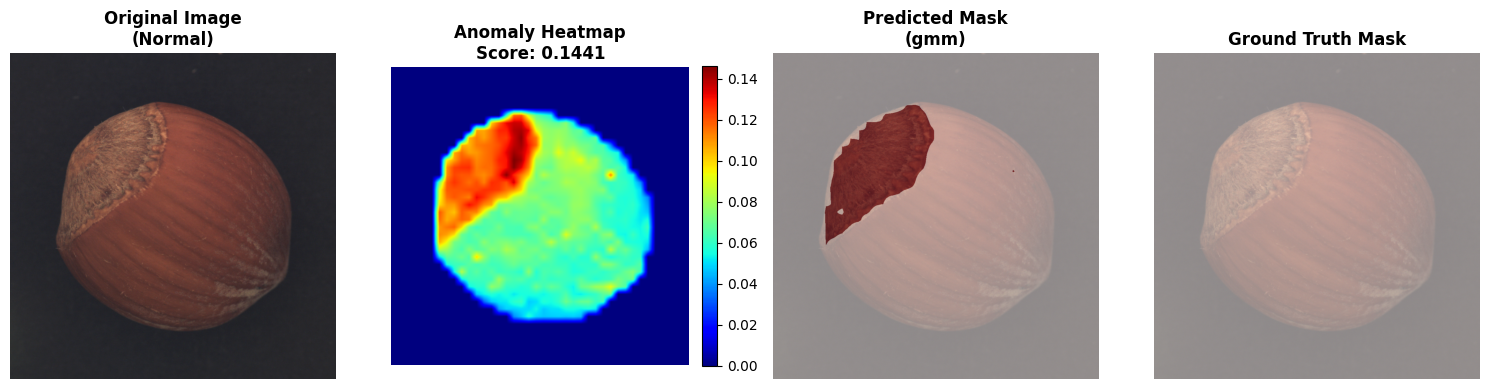

gmm


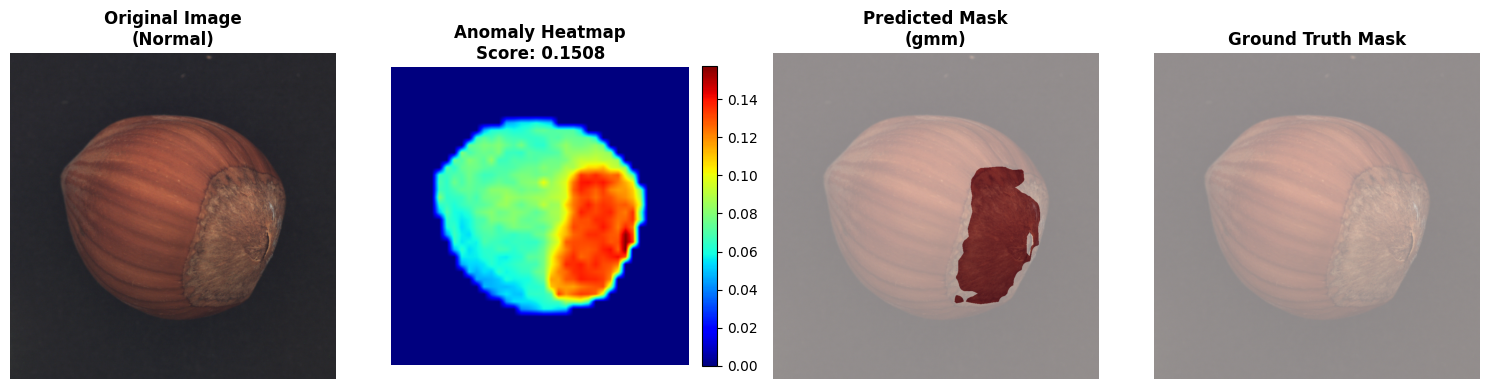

gmm


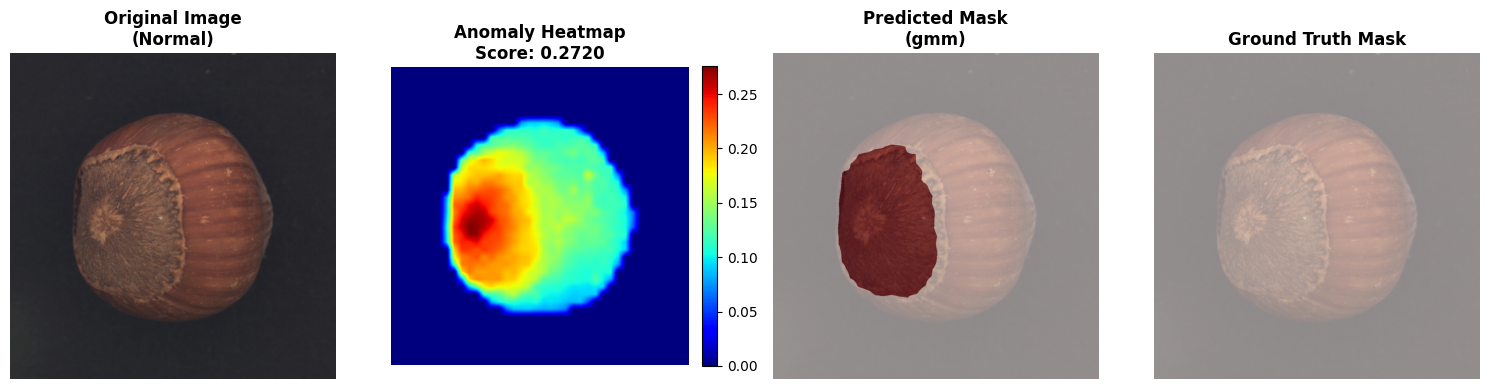

gmm


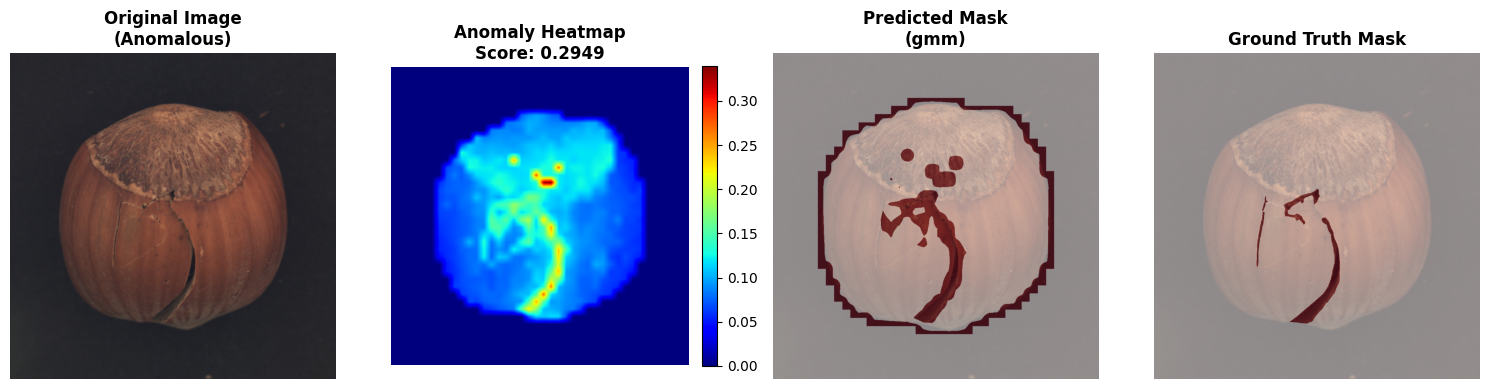

gmm


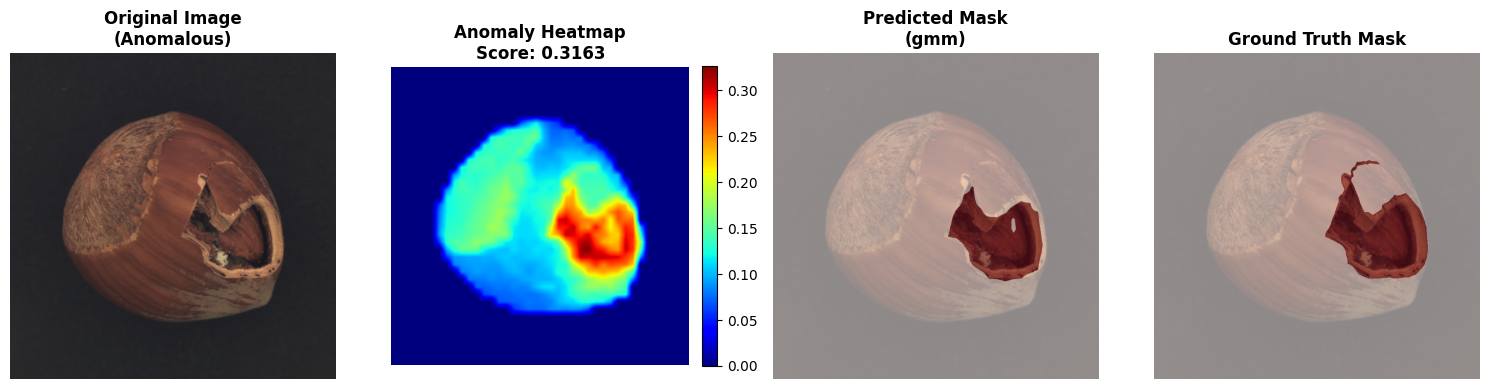

gmm


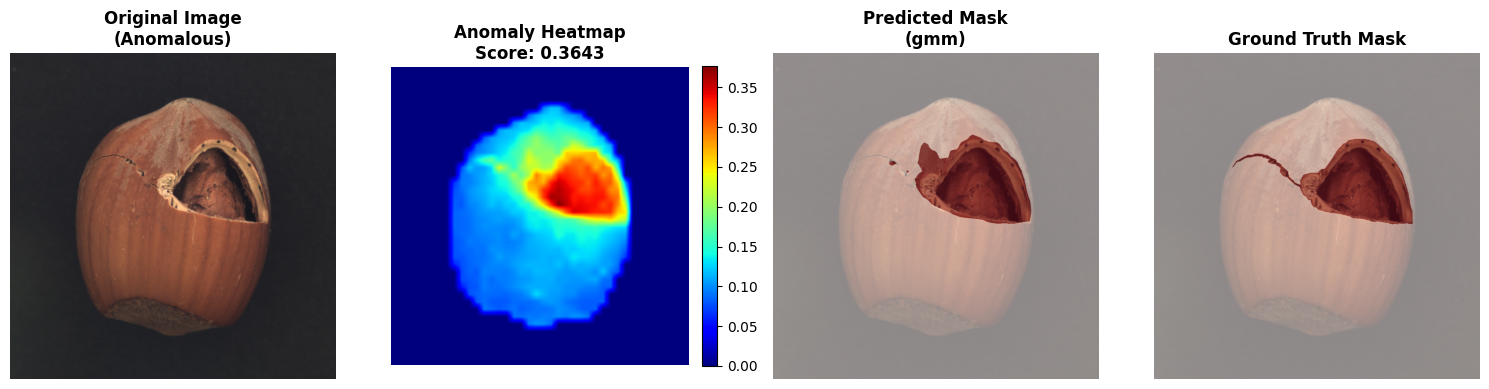

In [6]:
# Visualize a grid of results
from evaluation.visualization import plot_result_grid

ref_images, test_images, test_labels, test_masks = load_mvtec_data(
  dataset_path,
  'hazelnut',
)
plot_result_grid(
  results=test_result,
  test_images=test_images,
  test_labels=test_labels,
  test_masks=test_masks,
  sigma=0,
  num_display=6,  # number of examples to show
)

## 3. Run Complete Evaluation

In [7]:
# Run evaluation
results = run_evaluation(
    method_fn=run_few_shot,
    method_name='few_shot',
    model=model,
    dataset_path=dataset_path,
    objects=objects_to_eval,
    k_values=CONFIG['k_values'],
    method_kwargs={
        'use_rotation': CONFIG['use_rotation'], 
        'use_masking': CONFIG['use_masking'], 
        'masking_method': CONFIG['masking_method'], 
        'segmentation_method': CONFIG['segmentation_method'], 
        'k_neighbors': CONFIG['k_neighbors']
    }
)

results.description = f"Few-shot: rotation={CONFIG['use_rotation']}, masking={CONFIG['use_masking']}"
results.save(CONFIG['output_dir'] / 'experiment_results')
print('Evaluation complete and saved')

Evaluation of anomaly detection with:  few_shot

Evaluating: bottle

Loaded 8 reference images for bottle
Loaded 83 test images (63 anomalous, 20 normal)
Running 1_shot evaluation on bottle...
Building memory bank from 1 images...
Rotation augmentation: True


Processing reference images:   0%|          | 0/1 [00:00<?, ?it/s]

Memory bank built! Index size: 12800, hnswlib HNSW index


Detecting anomalies (bottle):   0%|          | 0/83 [00:00<?, ?it/s]

Running 2_shot evaluation on bottle...
Building memory bank from 2 images...
Rotation augmentation: True


...

Running 8_shot evaluation on zipper...
Building memory bank from 8 images...
Rotation augmentation: True


Processing reference images:   0%|          | 0/8 [00:00<?, ?it/s]

Memory bank built! Index size: 102400, hnswlib HNSW index


Detecting anomalies (zipper):   0%|          | 0/151 [00:00<?, ?it/s]

Evaluation complete and saved


## 3b. Run Zero-Shot Evaluation

In [8]:
# Run zero-shot evaluation
# Zero-shot uses leave-one-out approach: for each test image, all other test images form the memory bank
zero_shot_results = run_evaluation(
    method_fn=run_zero_shot,
    method_name='zero_shot',
    model=model,
    dataset_path=dataset_path,
    objects=objects_to_eval,
    k_values=[1],  # k_value doesn't matter for zero-shot, just need one iteration
    method_kwargs={
        'use_masking': CONFIG['use_masking'],
        'masking_method': CONFIG['masking_method'], 
        'segmentation_method': CONFIG['segmentation_method'],
    }
)

zero_shot_results.description = f"Zero-shot: masking={CONFIG['use_masking']}"
zero_shot_results.save(CONFIG['output_dir'] / 'zero_shot_results')
print('Zero-shot evaluation complete and saved')


Evaluation of anomaly detection with:  zero_shot

Evaluating: bottle

Loaded 1 reference images for bottle
Loaded 83 test images (63 anomalous, 20 normal)
Running zero_shot evaluation on bottle...


Detecting anomalies (bottle):   0%|          | 0/83 [00:00<?, ?it/s]

Building memory bank from 82 images...
Rotation augmentation: False


Processing reference images:   0%|          | 0/82 [00:00<?, ?it/s]

Memory bank built! Index size: 131200, hnswlib HNSW index
Building memory bank from 82 images...
Rotation augmentation: False


...

Memory bank built! Index size: 240000, hnswlib HNSW index
Building memory bank from 150 images...
Rotation augmentation: False


Processing reference images:   0%|          | 0/150 [00:00<?, ?it/s]

Memory bank built! Index size: 240000, hnswlib HNSW index
Building memory bank from 150 images...
Rotation augmentation: False


Processing reference images:   0%|          | 0/150 [00:00<?, ?it/s]

Memory bank built! Index size: 240000, hnswlib HNSW index
Zero-shot evaluation complete and saved


## 4. Analyze Results

In [9]:
# Summary
summary = results.summary_table()
print('Summary Statistics:')
print(summary.to_string(index=False))

best = summary.iloc[0]
print(f"\nBest: {best['Method']} - AUROC: {best['Mean AUROC']:.4f}")

Summary Statistics:
Method  Mean AUROC  Std AUROC  Mean AU-PRO  Std AU-PRO  Mean Pixel AUROC  Mean Pixel F1  Mean IoU  Mean Cls Accuracy  Mean Cls Precision  Mean Cls Recall  Mean Cls F1  Total TP  Total FP  Total FN  Total TN  Num Objects
8_shot    0.958084   0.067575     0.818892    0.129696          0.923031       0.611108  0.152853           0.760580            0.754189         0.978184     0.849328      1233       385        25        82           15
4_shot    0.952683   0.079736     0.792587    0.121839          0.922000       0.606626  0.151297           0.756287            0.751318         0.976448     0.846473      1232       390        26        77           15
2_shot    0.943154   0.098061     0.787593    0.119813          0.919450       0.598134  0.148749           0.749550            0.744664         0.982612     0.843982      1240       407        18        60           15
1_shot    0.936968   0.101736     0.782722    0.146417          0.916383       0.592824  0.147300   

In [10]:
# Per-object
per_obj = results.per_object_table()
pivot = per_obj.pivot_table(index='Object', columns='Method', values='AUROC')
print('AUROC by Object:')
print(pivot.to_string())

AUROC by Object:
Method        1_shot    2_shot    4_shot    8_shot
Object                                            
bottle      1.000000  0.999206  0.999206  1.000000
cable       0.937219  0.948276  0.946214  0.954085
capsule     0.917431  0.934184  0.949342  0.968089
carpet      1.000000  1.000000  0.999599  1.000000
grid        0.955723  0.962406  0.960735  0.972431
hazelnut    0.980000  0.979643  0.986429  0.985714
leather     1.000000  1.000000  1.000000  1.000000
metal_nut   0.999022  0.999511  0.996090  1.000000
pill        0.939989  0.947081  0.939444  0.954173
screw       0.593154  0.608936  0.687641  0.738061
tile        1.000000  1.000000  1.000000  1.000000
toothbrush  0.991667  0.961111  0.991667  0.991667
transistor  0.838750  0.838333  0.858333  0.866250
wood        0.979825  0.983333  0.981579  0.983333
zipper      0.921744  0.985294  0.993960  0.957458


## 5. Visualizations

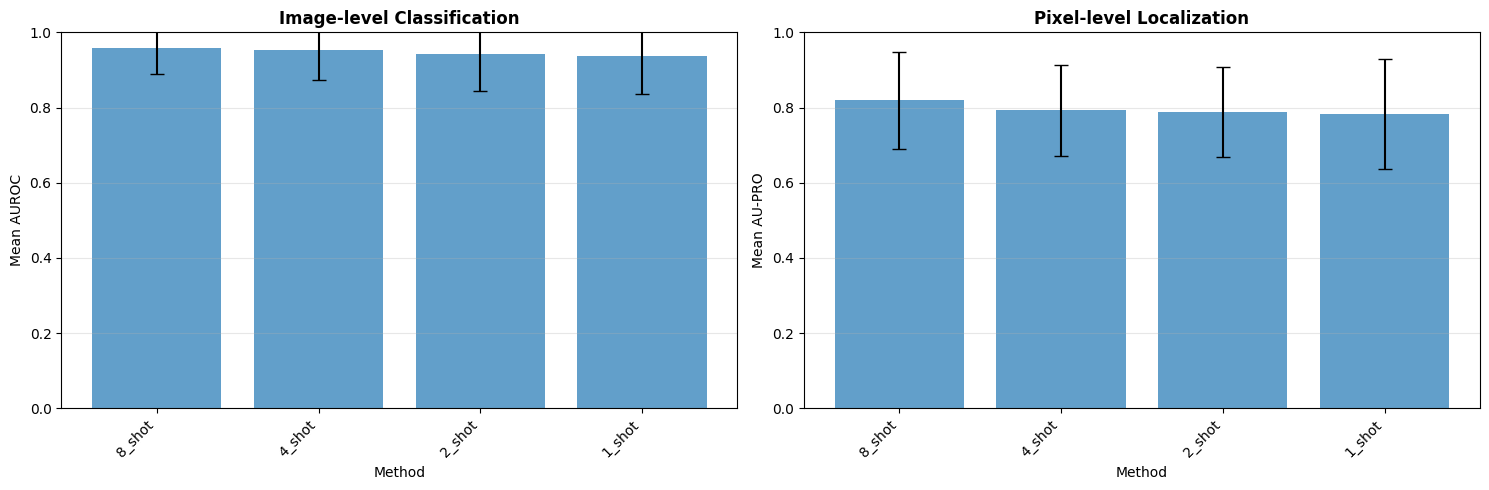

In [11]:
plot_method_comparison(results, metrics=['auroc', 'aupro'])

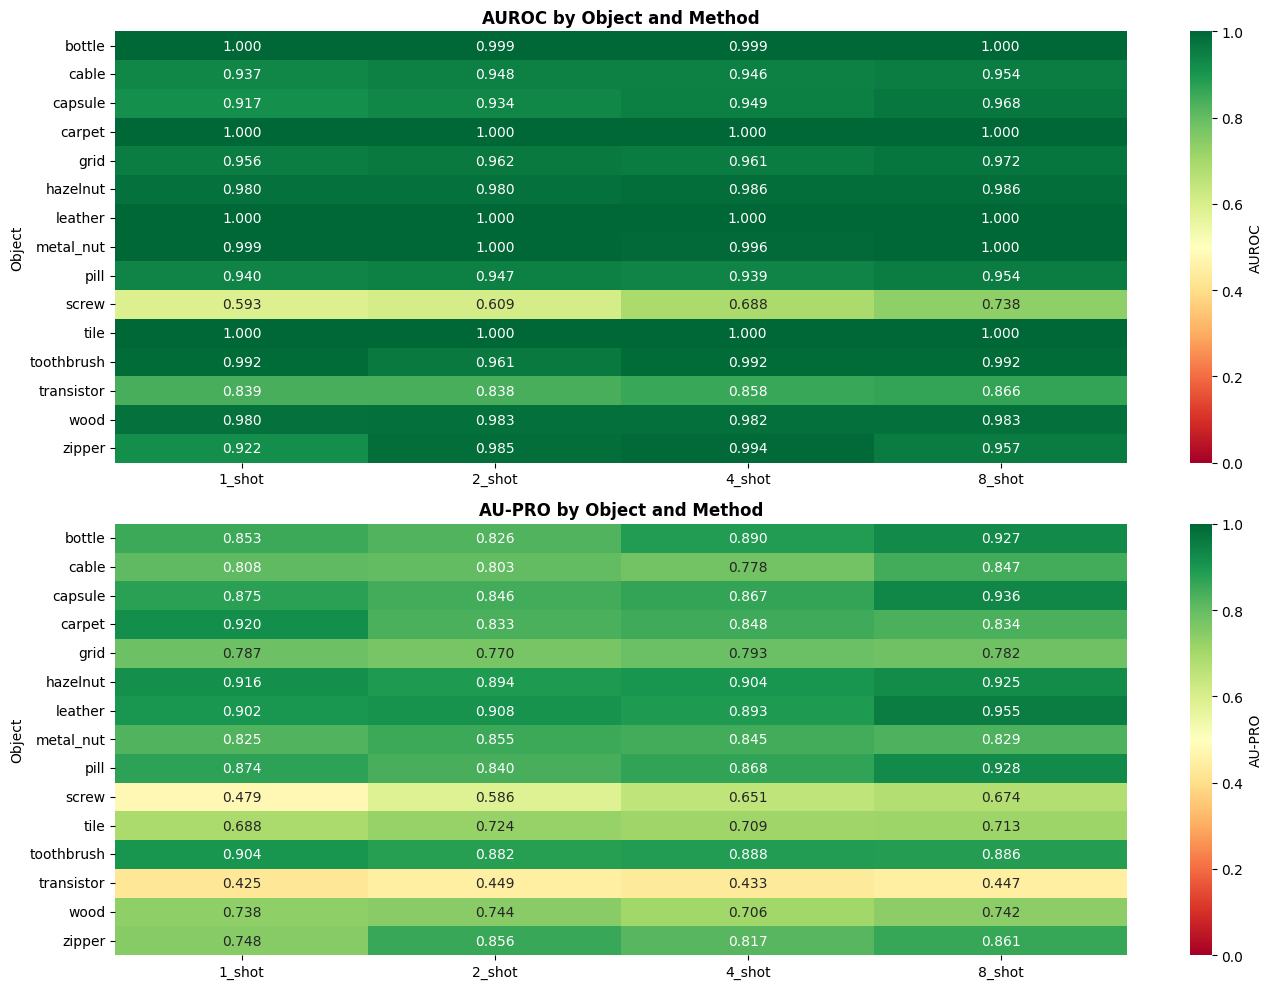

In [12]:
plot_object_heatmap(results, metrics=['AUROC', 'AU-PRO'])

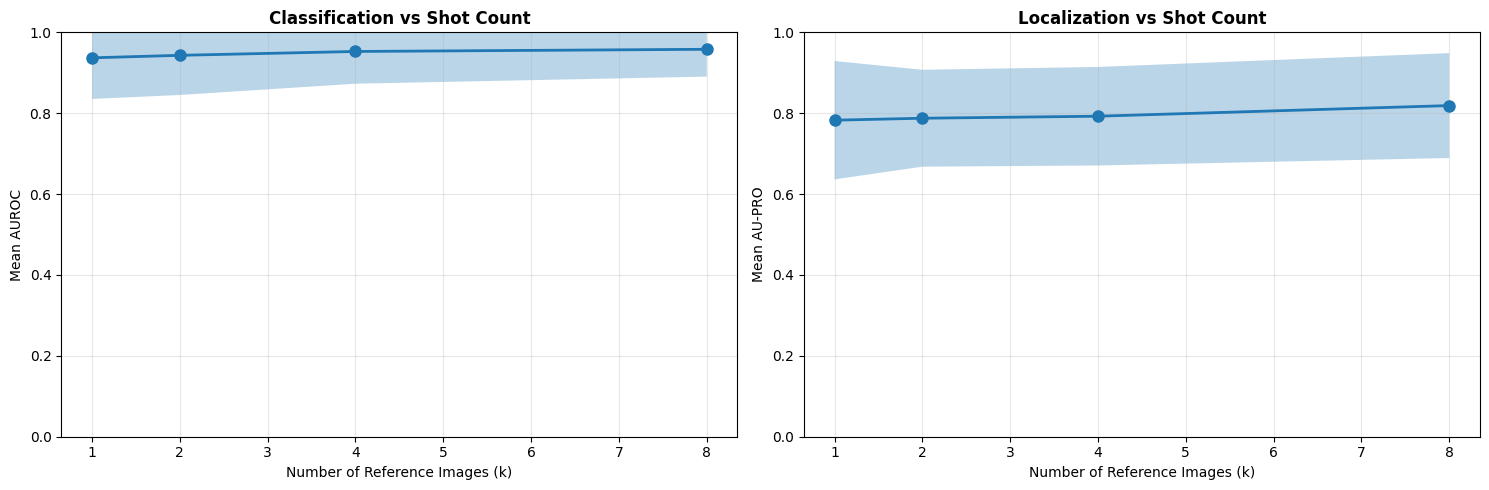


Improvement from 1-shot to 8-shot:
  AUROC: 0.9370 → 0.9581 (+2.3%)
  AUPRO: 0.7827 → 0.8189 (+4.6%)


In [13]:
if len(CONFIG['k_values']) > 1:
    plot_shot_count_analysis(results, k_values=CONFIG['k_values'], metrics=['auroc', 'aupro'])

## 6. Compare Methods

In [14]:
if len(results.list_methods()) >= 2:
    comp = results.compare_methods('1_shot', '8_shot', metric='auroc')
    print(comp.to_string(index=False))


Statistical Comparison (auroc):
  1_shot: 0.9370 ± 0.1053
  8_shot: 0.9581 ± 0.0699
  Paired t-test: t=-2.1791, p=0.0469
  Significant at α=0.05: Yes
    Object   1_shot   8_shot  Difference (B-A)  Improvement %
    bottle 1.000000 1.000000          0.000000       0.000000
     cable 0.937219 0.954085          0.016867       1.799640
   capsule 0.917431 0.968089          0.050658       5.521739
    carpet 1.000000 1.000000          0.000000       0.000000
      grid 0.955723 0.972431          0.016708       1.748252
  hazelnut 0.980000 0.985714          0.005714       0.583090
   leather 1.000000 1.000000          0.000000       0.000000
 metal_nut 0.999022 1.000000          0.000978       0.097847
      pill 0.939989 0.954173          0.014184       1.508996
     screw 0.593154 0.738061          0.144907      24.429855
      tile 1.000000 1.000000          0.000000       0.000000
toothbrush 0.991667 0.991667          0.000000       0.000000
transistor 0.838750 0.866250          0.027

## 7. Export Results

In [15]:
export_all(results, CONFIG['output_dir'] / 'exports')
print('✓ Results exported')

Exporting results in all formats...
Results exported to evaluation_results_clean\exports\results.json
Summary statistics saved to evaluation_results_clean\exports\summary.csv
Per-object results saved to evaluation_results_clean\exports\per_object.csv

All exports completed! Results saved to: evaluation_results_clean\exports
✓ Results exported


## 8. Compare Few-Shot vs Zero-Shot

In [16]:
# Merge few-shot and zero-shot results for comparison
combined_results = results.merge(zero_shot_results)
print(f"Combined methods: {combined_results.list_methods()}")
print(f"Objects evaluated: {len(combined_results.list_objects())}")

Combined methods: ['1_shot', '2_shot', '4_shot', '8_shot', 'zero_shot']
Objects evaluated: 15


In [17]:
# Summary table for all methods (few-shot variants + zero-shot)
combined_summary = combined_results.summary_table()
print('Combined Summary Statistics (Few-Shot + Zero-Shot):')
print(combined_summary.to_string(index=False))

Combined Summary Statistics (Few-Shot + Zero-Shot):
   Method  Mean AUROC  Std AUROC  Mean AU-PRO  Std AU-PRO  Mean Pixel AUROC  Mean Pixel F1  Mean IoU  Mean Cls Accuracy  Mean Cls Precision  Mean Cls Recall  Mean Cls F1  Total TP  Total FP  Total FN  Total TN  Num Objects
   8_shot    0.958084   0.067575     0.818892    0.129696          0.923031       0.611108  0.152853           0.760580            0.754189         0.978184     0.849328      1233       385        25        82           15
   4_shot    0.952683   0.079736     0.792587    0.121839          0.922000       0.606626  0.151297           0.756287            0.751318         0.976448     0.846473      1232       390        26        77           15
zero_shot    0.946042   0.084872     0.814980    0.121969          0.917277       0.588730  0.134893           0.719206            0.728490         0.962295     0.825673      1218       432        40        35           15
   2_shot    0.943154   0.098061     0.787593    0.11981

In [18]:
# Statistical comparison: Zero-Shot vs 8-Shot (best few-shot)
print("Statistical Comparison: Zero-Shot vs 8-Shot")
print("=" * 60)
comp_zs_8s = combined_results.compare_methods('zero_shot', '8_shot', metric='auroc')
print(comp_zs_8s.to_string(index=False))

Statistical Comparison: Zero-Shot vs 8-Shot

Statistical Comparison (auroc):
  zero_shot: 0.9460 ± 0.0879
  8_shot: 0.9581 ± 0.0699
  Paired t-test: t=-1.8635, p=0.0835
  Significant at α=0.05: No
    Object  zero_shot   8_shot  Difference (B-A)  Improvement %
    bottle   1.000000 1.000000          0.000000       0.000000
     cable   0.948088 0.954085          0.005997       0.632536
   capsule   0.936179 0.968089          0.031911       3.408607
    carpet   1.000000 1.000000          0.000000       0.000000
      grid   0.984962 0.972431         -0.012531      -1.272265
  hazelnut   0.961786 0.985714          0.023929       2.487932
   leather   1.000000 1.000000          0.000000       0.000000
 metal_nut   0.998045 1.000000          0.001955       0.195886
      pill   0.922804 0.954173          0.031369       3.399350
     screw   0.663251 0.738061          0.074810      11.279357
      tile   1.000000 1.000000          0.000000       0.000000
toothbrush   1.000000 0.991667     

In [19]:
# Per-object comparison table including zero-shot
combined_per_obj = combined_results.per_object_table()
combined_pivot = combined_per_obj.pivot_table(index='Object', columns='Method', values='AUROC')
print('AUROC by Object (All Methods):')
print(combined_pivot.to_string())

AUROC by Object (All Methods):
Method        1_shot    2_shot    4_shot    8_shot  zero_shot
Object                                                       
bottle      1.000000  0.999206  0.999206  1.000000   1.000000
cable       0.937219  0.948276  0.946214  0.954085   0.948088
capsule     0.917431  0.934184  0.949342  0.968089   0.936179
carpet      1.000000  1.000000  0.999599  1.000000   1.000000
grid        0.955723  0.962406  0.960735  0.972431   0.984962
hazelnut    0.980000  0.979643  0.986429  0.985714   0.961786
leather     1.000000  1.000000  1.000000  1.000000   1.000000
metal_nut   0.999022  0.999511  0.996090  1.000000   0.998045
pill        0.939989  0.947081  0.939444  0.954173   0.922804
screw       0.593154  0.608936  0.687641  0.738061   0.663251
tile        1.000000  1.000000  1.000000  1.000000   1.000000
toothbrush  0.991667  0.961111  0.991667  0.991667   1.000000
transistor  0.838750  0.838333  0.858333  0.866250   0.875417
wood        0.979825  0.983333  0.98157

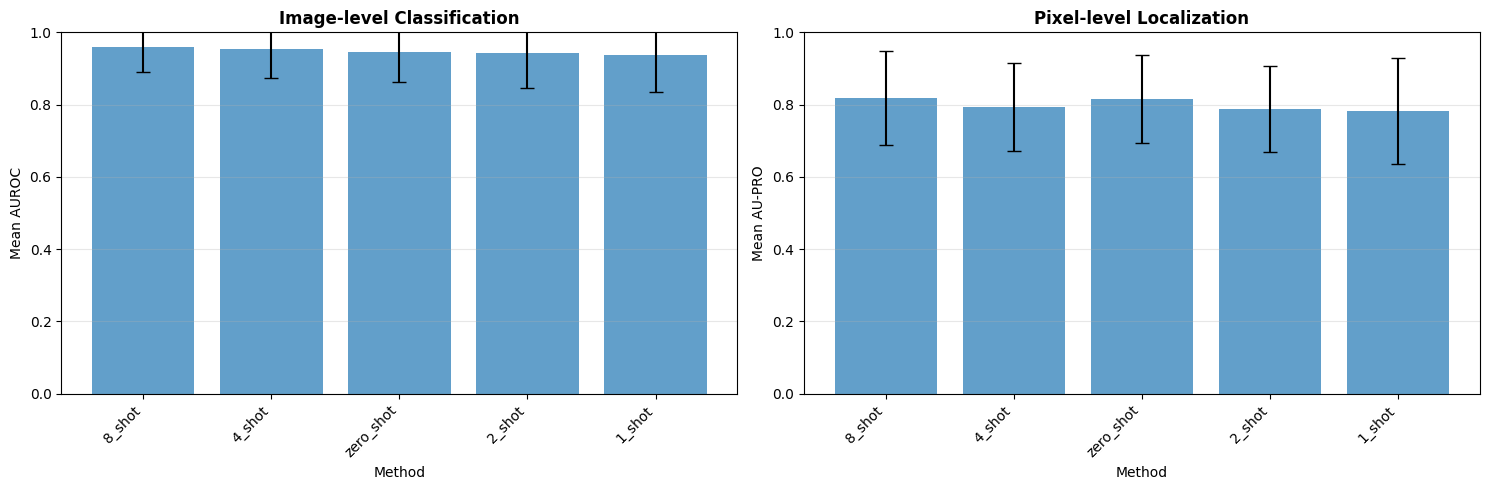

In [20]:
# Visualize method comparison including zero-shot
plot_method_comparison(combined_results, metrics=['auroc', 'aupro'])

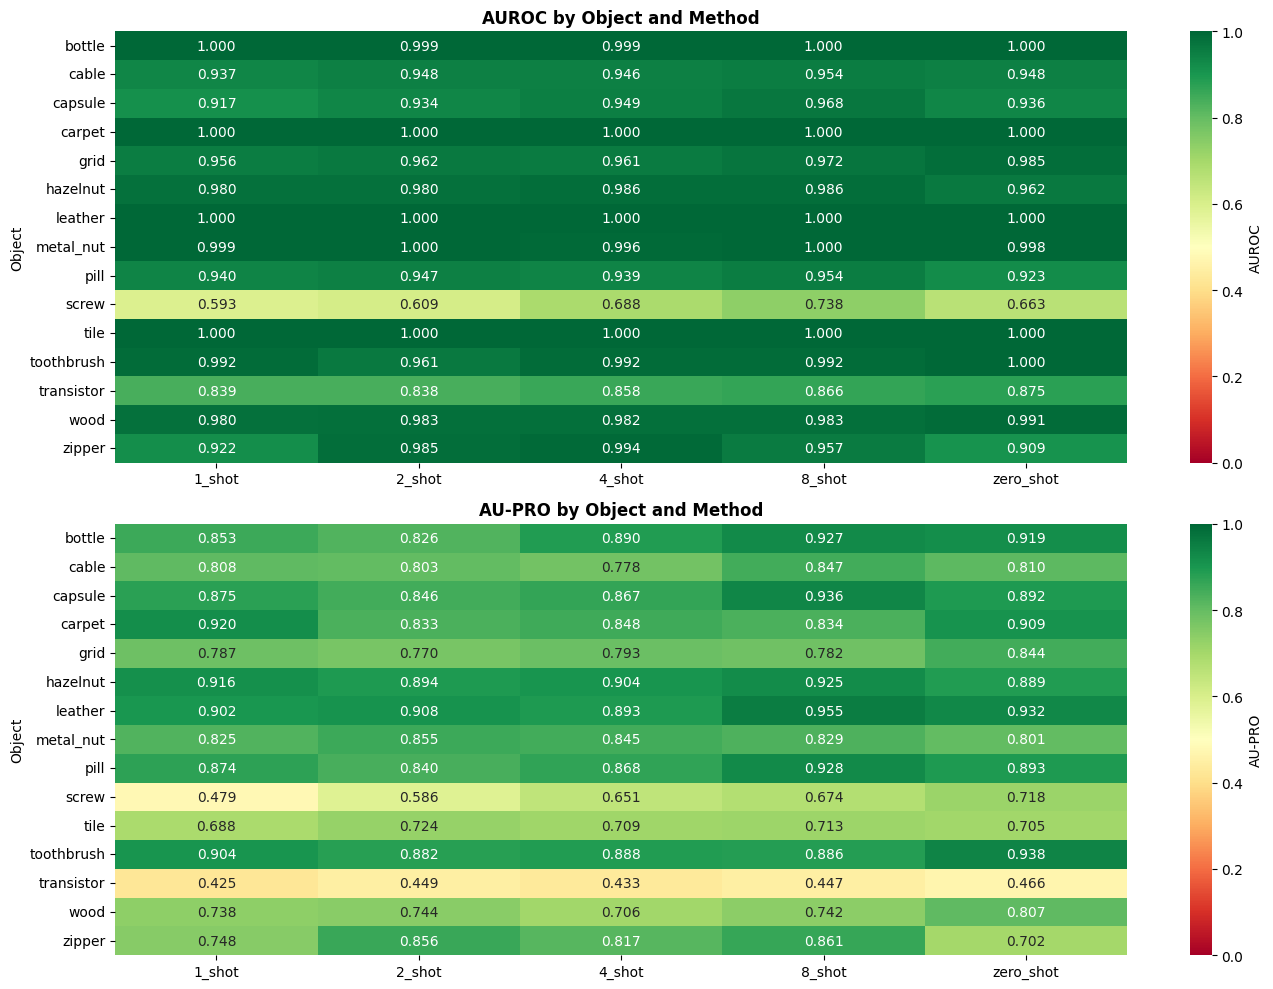

In [21]:
# Heatmap comparing all methods including zero-shot
plot_object_heatmap(combined_results, metrics=['AUROC', 'AU-PRO'])

In [23]:
# Export combined results
combined_results.save(CONFIG['output_dir'] / 'combined_results')
export_all(combined_results, CONFIG['output_dir'] / 'combined_exports')
print('Combined results exported')

Exporting results in all formats...
Results exported to evaluation_results_clean\combined_exports\results.json
Summary statistics saved to evaluation_results_clean\combined_exports\summary.csv
Per-object results saved to evaluation_results_clean\combined_exports\per_object.csv

All exports completed! Results saved to: evaluation_results_clean\combined_exports
Combined results exported
